In [3]:
from pathlib import Path
import shutil

In [4]:
source = Path(r"C:\Users\Samuel\Downloads\SRC_NEW")
target = Path(r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata")

years = ["2015", "2045"]
variants = ["Jahr", "Somm", "Wint"]
test = (year for year in years)
for folder in source.glob("KR_*"):
    if not folder.is_dir():
        continue
    number = folder.name.replace("KR_","")

    for file in folder.rglob("*.dat"):
        f_name = file.name

        year = next((year for year in years if year in f_name), None)

        variant = next((variant for variant in variants if variant in f_name), None)

        if year is None:
            print(f"Kein Jahr erkannt: {file}")
            continue

        if variant is None:
            print(f"Keine Variante erkannt: {file}")
            continue

        dest = target/ f"TRY{year}"/number
        dest.mkdir(parents=True, exist_ok=True)

        t_file = dest/ file.name
        print(f"{file} -> {t_file}")

        shutil.copy2(file, t_file)




C:\Users\Samuel\Downloads\SRC_NEW\KR_01\TRY_532217077767\TRY2015_532217077767_Jahr.dat -> C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2015\01\TRY2015_532217077767_Jahr.dat
C:\Users\Samuel\Downloads\SRC_NEW\KR_01\TRY_532217077767\TRY2015_532217077767_Somm.dat -> C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2015\01\TRY2015_532217077767_Somm.dat
C:\Users\Samuel\Downloads\SRC_NEW\KR_01\TRY_532217077767\TRY2015_532217077767_Wint.dat -> C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2015\01\TRY2015_532217077767_Wint.dat
C:\Users\Samuel\Downloads\SRC_NEW\KR_01\TRY_532217077767\TRY2045_532217077767_Jahr.dat -> C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2045\01\TRY2045_532217077767_Jahr.dat
C:\Users\Samuel\Downloads\SRC_NEW\KR_01\TRY_532217077767\TRY2045_532217077767_Somm.dat -> C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsi

KeyboardInterrupt: 

In [58]:
print(next(test, None))

None


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def compare_TRYs(directory, keyword, variable="t"):

    columns = [
        "RW", "HW", "MM", "DD", "HH",
        "t", "p", "WR", "WG", "N", "x", "RF",
        "B", "D", "A", "E", "IL"
    ]

    directory = Path(directory)

    # Find matching files
    files = sorted([
        f for f in directory.glob("*.dat")
        if keyword.lower() in f.name.lower()
    ])

    if not files:
        raise ValueError(f"No .dat files containing '{keyword}' found.")

    daily_data = {}
    monthly_data = {}

    for file in files:

        # Find beginning of data after ***
        with open(file, "r", encoding="latin1") as f:
            lines = f.readlines()

        start = next(
            i for i, line in enumerate(lines)
            if line.strip().startswith("***")
        ) + 1

        # Read data
        df = pd.read_csv(
            file,
            sep=r"\s+",
            names=columns,
            skiprows=start
        )

        # Create day of year
        date = pd.to_datetime({
            "year": 2015,
            "month": df["MM"],
            "day": df["DD"]
        })

        df["day_of_year"] = date.dt.dayofyear

        # -----------------------------------
        # DAILY averages for plotting
        # -----------------------------------
        daily = df.groupby("day_of_year")[variable].mean()

        daily_data[file.stem] = daily

        # -----------------------------------
        # MONTHLY averages for comparison
        # -----------------------------------
        monthly = df.groupby("MM")[variable].mean()

        monthly_data[file.stem] = monthly


    daily_data = pd.DataFrame(daily_data)
    monthly_data = pd.DataFrame(monthly_data)


    # =======================================
    # Plot DAILY averages
    # =======================================

    plt.figure(figsize=(12, 6))

    for name in daily_data.columns:
        plt.plot(
            daily_data.index,
            daily_data[name],
            label=name,
            linewidth=1.2
        )

    plt.xlabel("Day of year")
    plt.ylabel(variable)
    plt.title(f"Daily average {variable}")
    plt.xlim(1, 365)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # =======================================
    # Monthly differences
    # =======================================

    differences = pd.DataFrame({
        "mean": monthly_data.mean(axis=1),
        "std": monthly_data.std(axis=1),
        "min": monthly_data.min(axis=1),
        "max": monthly_data.max(axis=1)
    })

    differences["range"] = (
        differences["max"] - differences["min"]
    )

    print("\nMonthly averages:")
    print(monthly_data.round(2))

    print("\nMonthly differences between TRYs:")
    print(differences.round(2))

    return daily_data, monthly_data, differences

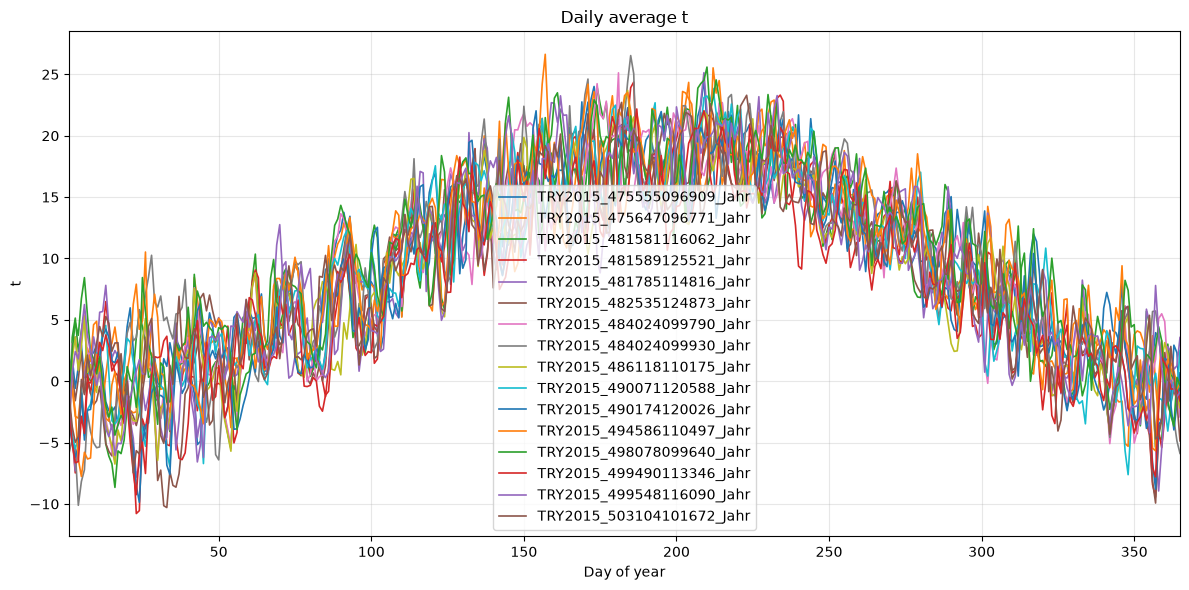


Monthly averages:
    TRY2015_475555096909_Jahr  TRY2015_475647096771_Jahr  \
MM                                                         
1                        0.37                       0.64   
2                        1.60                       1.75   
3                        5.76                       5.15   
4                        9.72                       9.29   
5                       14.33                      14.45   
6                       17.29                      17.44   
7                       18.80                      18.63   
8                       18.64                      18.52   
9                       14.52                      14.24   
10                      10.41                      10.16   
11                       5.07                       4.63   
12                       1.40                       1.24   

    TRY2015_481581116062_Jahr  TRY2015_481589125521_Jahr  \
MM                                                         
1                   

In [6]:
daily, monthly, differences = compare_TRYs(
    directory=r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2015\13",
    keyword="Jahr",
    variable="t"
)

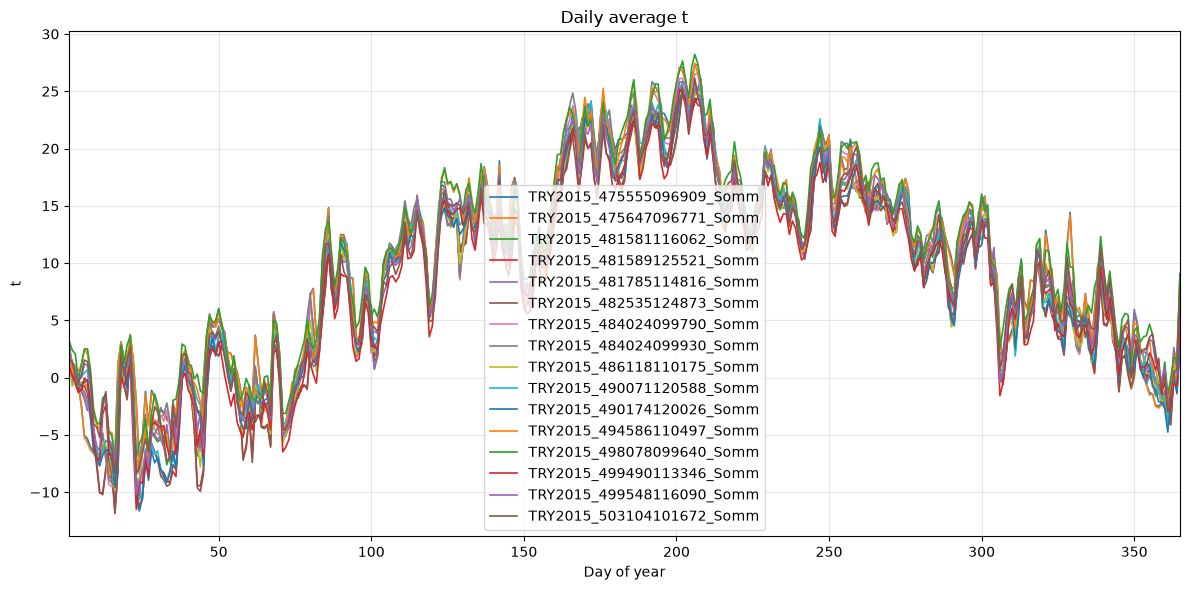


Monthly averages:
    TRY2015_475555096909_Somm  TRY2015_475647096771_Somm  \
MM                                                         
1                       -2.82                      -3.01   
2                        0.28                       0.13   
3                        3.24                       3.17   
4                        9.07                       8.89   
5                       13.92                      13.76   
6                       18.12                      17.77   
7                       22.72                      22.30   
8                       15.28                      15.15   
9                       17.21                      16.90   
10                      12.83                      12.62   
11                       7.25                       7.05   
12                       2.13                       1.98   

    TRY2015_481581116062_Somm  TRY2015_481589125521_Somm  \
MM                                                         
1                   

In [7]:
daily, monthly, differences = compare_TRYs(
    directory=r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2015\13",
    keyword="Somm",
    variable="t"
)

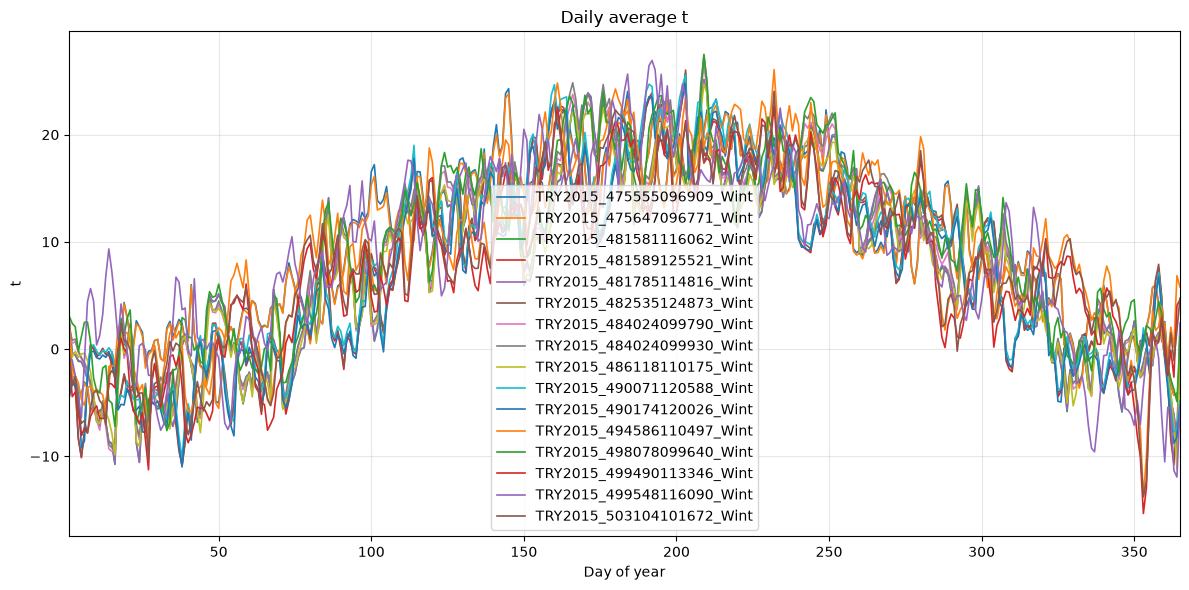


Monthly averages:
    TRY2015_475555096909_Wint  TRY2015_475647096771_Wint  \
MM                                                         
1                       -1.36                      -1.53   
2                        0.61                       0.43   
3                        4.32                       4.19   
4                       12.37                      11.97   
5                       15.98                      15.67   
6                       16.84                      16.60   
7                       18.74                      18.43   
8                       18.55                      18.31   
9                       13.59                      13.29   
10                      10.65                      10.41   
11                       4.57                       4.37   
12                       1.28                       1.15   

    TRY2015_481581116062_Wint  TRY2015_481589125521_Wint  \
MM                                                         
1                   

In [8]:
daily, monthly, differences = compare_TRYs(
    directory=r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2015\13",
    keyword="Wint",
    variable="t"
)

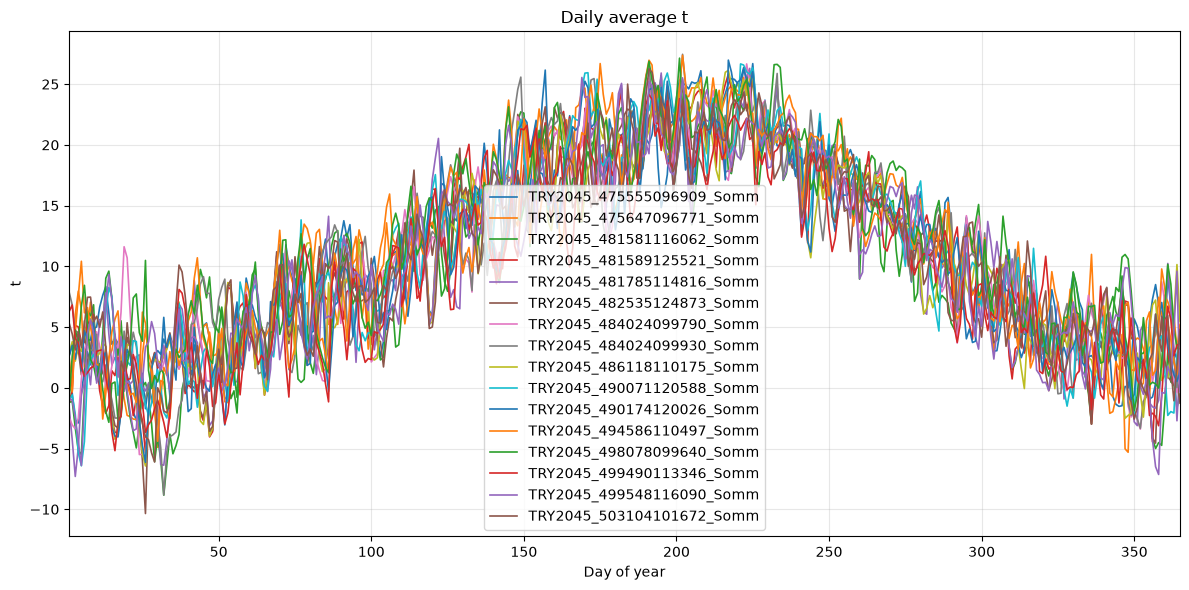


Monthly averages:
    TRY2045_475555096909_Somm  TRY2045_475647096771_Somm  \
MM                                                         
1                        1.57                       1.56   
2                        3.29                       3.21   
3                        7.25                       6.98   
4                        9.91                      10.18   
5                       15.38                      15.57   
6                       19.45                      19.83   
7                       21.86                      22.05   
8                       21.84                      21.73   
9                       17.28                      17.18   
10                      11.00                      10.74   
11                       5.63                       5.69   
12                       3.05                       3.08   

    TRY2045_481581116062_Somm  TRY2045_481589125521_Somm  \
MM                                                         
1                   

In [10]:
daily, monthly, differences = compare_TRYs(
    directory=r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2045\13",
    keyword="Somm",
    variable="t"
)